In [44]:
import random
from pathlib import Path
from typing import Iterable

import pandas as pd
import matplotlib.pyplot as plt
import networkit as nk
import networkx as nx
import numpy as np
from networkit.embedding import Node2Vec
from sklearn.metrics import f1_score
import seaborn as sns

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
nk.engineering.setNumberOfThreads(1)

## Networkit documentation
https://networkit.github.io/dev-docs/python_api/modules.html

## Loading network

In [11]:
data_path = Path('./citeseer/citeseer.adjlist')
file = open(data_path, "rb")
G = nx.read_adjlist(file)
nk_G = nk.nxadapter.nx2nk(G)

## Connected components and betweenness centrality

In [17]:
nk_com_time = %timeit -q -o nk.components.ConnectedComponents(nk_G).run().numberOfComponents()
nx_com_time = %timeit -q -o len(list(nx.connected_components(G)))

print("Connected components")
print(f"   NetworKit: {nk_com_time}")
print(f"   NetworkX: {nx_com_time}")

nk_bc_time = %timeit -q -o nk.centrality.EstimateBetweenness(nk_G, 100).run()
nx_bc_time = %timeit -q -o nx.betweenness_centrality(G, k=100)

print("\nBetweenness centrality")
print(f"   NetworKit: {nk_bc_time}")
print(f"   NetworkX: {nx_bc_time}")

Connected components
   NetworKit: 92.5 μs ± 3.49 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
   NetworkX: 1.75 ms ± 269 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)

Betweenness centrality
   NetworKit: 38.2 ms ± 2.45 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
   NetworkX: 365 ms ± 39.1 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


## Network analysis


Original graph

Network Properties:
nodes, edges			3327, 4552
directed?			False
weighted?			False
isolated nodes			48
self-loops			0
density				0.000823
clustering coefficient		0.141471
min/max/avg degree		0, 99, 2.736399
degree assortativity		0.142213
number of connected components	438
size of largest component	2120 (63.72 %)
  Top 3 Betweenness: ['242: 730905.19', '60: 616057.75', '74: 582368.21']
  Top 3 Closeness Centrality:    ['60: 0.1460', '230: 0.1369', '129: 0.1351']


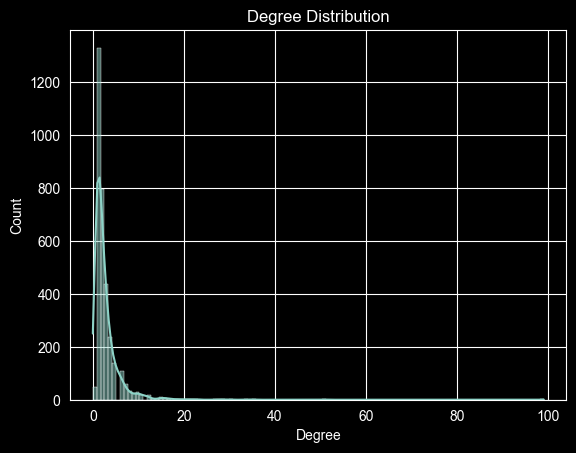

In [46]:
from networkit import Graph


def analysis(name: str, G: Graph, overview: bool = True):
    print(f"\n{name}\n")
    if overview:
        nk.overview(G)

    betweenness_centrality = nk.centrality.EstimateBetweenness(G, 100)
    betweenness_centrality.run()
    print("  Top 3 Betweenness:", [f"{n}: {s:.2f}" for n, s in betweenness_centrality.ranking()[:3]])

    harmonic = nk.centrality.HarmonicCloseness(G)
    harmonic.run()
    print("  Top 3 Closeness Centrality:   ", [f"{n}: {s:.4f}" for n, s in harmonic.ranking()[:3]])

def plot_degree(G: Graph):
    degree = nk.centrality.DegreeCentrality(G)
    degree.run()
    scores = degree.scores()

    sns.histplot(scores, kde=True)
    plt.xlabel("Degree")
    plt.ylabel("Count")
    plt.title("Degree Distribution")
    plt.show()

analysis("Original graph", nk_G)
plot_degree(nk_G)

## Sparsification

sparsyfikacja jest jednym z typów redukcji grafu, która wybiera istotne węzły i krawędzie, odrzucając pozostałe. W trakcie działania procesu dla danego grafu $G = (A, X)$,  model sparsyfikacji grafu wybiera istniejące węzły lub krawędzie z grafu $G$, tworząc $G' = (A', X')$. Innymi słowy, elementy $A'$ lub $X'$ są podzbiorem elementów w $A$ lub $X$.


Random Edge Sparsifier

Network Properties:
nodes, edges			3327, 1112
directed?			False
weighted?			False
isolated nodes			1851
self-loops			0
density				0.000201
clustering coefficient		0.008931
min/max/avg degree		0, 24, 0.668470
degree assortativity		0.155243
number of connected components	2284
size of largest component	268 (8.06 %)
  Top 3 Betweenness: ['60: 36818.06', '230: 36327.66', '487: 36177.36']
  Top 3 Closeness Centrality:    ['60: 0.0241', '230: 0.0214', '62: 0.0190']


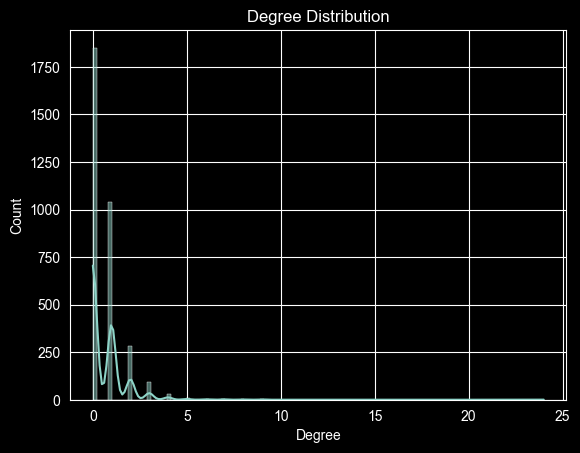


Local Degree Sparsifier

Network Properties:
nodes, edges			3327, 2817
directed?			False
weighted?			False
isolated nodes			48
self-loops			0
density				0.000509
clustering coefficient		0.000000
min/max/avg degree		0, 99, 1.693417
degree assortativity		-0.032334
number of connected components	510
size of largest component	634 (19.06 %)
  Top 3 Betweenness: ['230: 318046.24', '60: 256805.12', '129: 249387.66']
  Top 3 Closeness Centrality:    ['60: 0.0761', '230: 0.0671', '129: 0.0616']


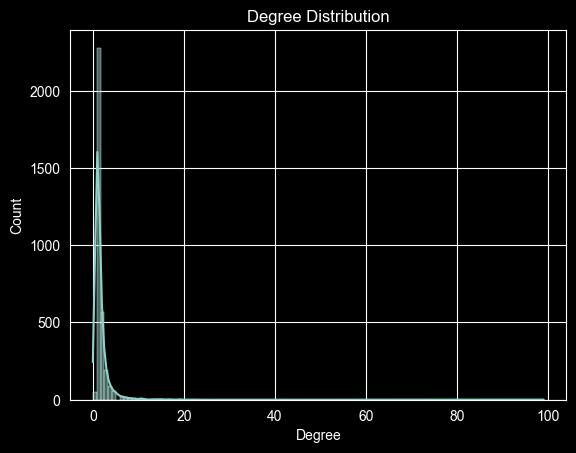

In [47]:
edge_ratio = 0.25
nk_G.indexEdges()

random_edge_sparsifier = nk.sparsification.RandomEdgeSparsifier()
random_graph = random_edge_sparsifier.getSparsifiedGraphOfSize(nk_G, edge_ratio)
analysis("Random Edge Sparsifier", random_graph)
plot_degree(random_graph)

local_deg_sparsifier = nk.sparsification.LocalDegreeSparsifier()
local_deg_graph = local_deg_sparsifier.getSparsifiedGraphOfSize(nk_G, edge_ratio)
analysis("Local Degree Sparsifier", local_deg_graph)
plot_degree(local_deg_graph)


EDGE RATIO: 0.1

Original graph

  Top 3 Betweenness: ['242: 744584.96', '60: 631554.27', '74: 570639.87']
  Top 3 Closeness Centrality:    ['60: 0.1460', '230: 0.1369', '129: 0.1351']

Random Edge Sparsifier

  Top 3 Betweenness: ['195: 212.93', '105: 166.35', '57: 149.72']
  Top 3 Closeness Centrality:    ['60: 0.0036', '195: 0.0033', '57: 0.0030']

Local Degree Sparsifier

  Top 3 Betweenness: ['230: 306085.69', '60: 275239.75', '129: 255141.22']
  Top 3 Closeness Centrality:    ['60: 0.0761', '230: 0.0671', '129: 0.0616']

EDGE RATIO: 0.25

Original graph

  Top 3 Betweenness: ['242: 1011921.44', '60: 706853.39', '536: 700818.14']
  Top 3 Closeness Centrality:    ['60: 0.1460', '230: 0.1369', '129: 0.1351']

Random Edge Sparsifier

  Top 3 Betweenness: ['60: 29927.10', '230: 24294.25', '129: 14643.33']
  Top 3 Closeness Centrality:    ['60: 0.0258', '230: 0.0225', '55: 0.0199']

Local Degree Sparsifier

  Top 3 Betweenness: ['230: 236361.24', '60: 220864.02', '129: 142716.25']
  T

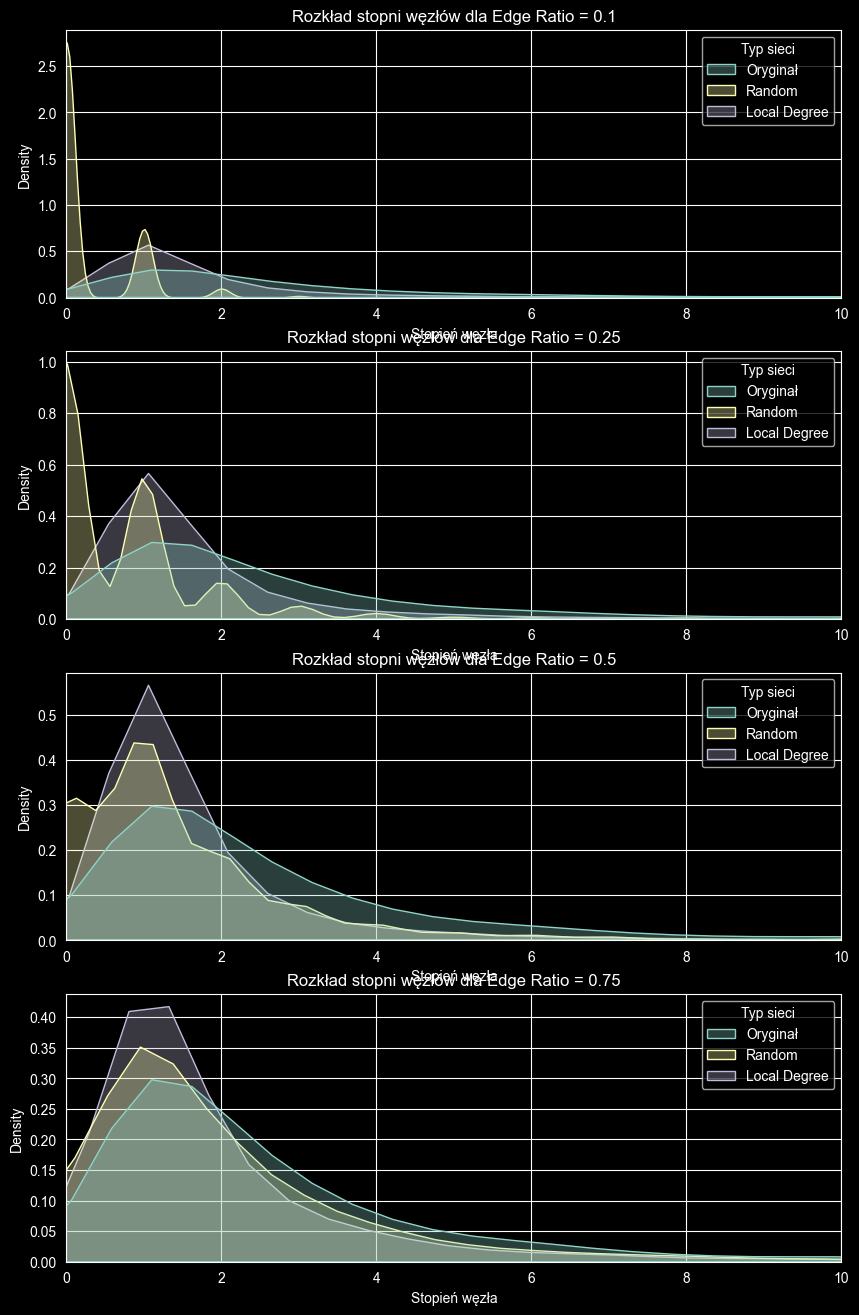

<Figure size 640x480 with 0 Axes>

In [51]:
ratios = [0.10, 0.25, 0.50, 0.75]

degree_orig = nk.centrality.DegreeCentrality(nk_G)
degree_orig.run()
scores_orig = degree_orig.scores()

fig, axes = plt.subplots(len(ratios), 1, figsize=(10, 4 * len(ratios)))

for idx, ratio in enumerate(ratios):
    print(f"\nEDGE RATIO: {ratio}")
    analysis("Original graph", nk_G, overview=False)

    random_edge_sparsifier = nk.sparsification.RandomEdgeSparsifier()
    random_graph = random_edge_sparsifier.getSparsifiedGraphOfSize(nk_G, ratio)
    analysis("Random Edge Sparsifier", random_graph, overview=False)

    degree_rand = nk.centrality.DegreeCentrality(random_graph)
    degree_rand.run()
    scores_rand = degree_rand.scores()

    local_deg_sparsifier = nk.sparsification.LocalDegreeSparsifier()
    local_deg_graph = local_deg_sparsifier.getSparsifiedGraphOfSize(nk_G, ratio)
    analysis("Local Degree Sparsifier", local_deg_graph, overview=False)

    degree_loc = nk.centrality.DegreeCentrality(local_deg_graph)
    degree_loc.run()
    scores_loc = degree_loc.scores()

    df = pd.DataFrame({
        "Stopień węzła": scores_orig + scores_rand + scores_loc,
        "Typ sieci": ["Oryginał"]*len(scores_orig) + ["Random"]*len(scores_rand) + ["Local Degree"]*len(scores_loc)
    })

    sns.kdeplot(data=df, x="Stopień węzła", hue="Typ sieci", fill=True, alpha=0.3, ax=axes[idx], common_norm=False)
    axes[idx].set_title(f"Rozkład stopni węzłów dla Edge Ratio = {ratio}")
    axes[idx].set_xlim(left=0, right=10)

plt.show()
plt.tight_layout()

## Link prediction

celem zadania jest przewidywanie,
czy pomiędzy daną parą węzłów powinna istnieć krawędź.
Problem ten jest formułowany jako zadanie klasyfikacji binarnej,
gdzie:
- klasa pozytywna odpowiada istniejącym krawędziom,
- klasa negatywna odpowiada parom węzłów bez połączenia.

W naszym przypadku celem modelu jest odtworzenie struktury
zredukowanego grafu na podstawie dostępnych danych.

### Negative sampling

proces polegający na losowaniu par węzłów,
które **nie są połączone krawędzią** w grafie.

Jest to kluczowy krok w zadaniu link prediction, ponieważ:
- graf nie zawiera jawnych przykładów negatywnych,
- model klasyfikacyjny wymaga danych obu klas,
- losowanie negatywnych krawędzi umożliwia zbalansowanie zbioru danych.

### Cechy krawędzi (edge features)

w tym ćwiczeniu cechy krawędzi są budowane na podstawie
**embeddingów węzłów uzyskanych metodą Node2Vec**.

Dla każdej krawędzi (u, v):
- pobierane są embeddingi węzłów u i v,
- łączone są w jeden wektor cech.


In [53]:
def sample_negative_edges(
    G: nk.Graph,
    num_samples: int,
    forbidden_edges: set[tuple[int, int]] | None = None,
) -> np.ndarray:
    """
    Funkcja powinna losować "negatywne krawędzie" w grafie, czyli takie, które nie istnieją w grafie G.

    Parametry
    G : nk.Graph
        Graf wejściowy
    num_samples : int
        Liczba negatywnych krawędzi do wylosowania
    forbidden_edges : set[tuple[int,int]] lub None
        Zbiór krawędzi, których NIE można wylosować (np. istniejących w grafie)

    Wskazówki:
    - Pomiń pętle (u==v)
    - Normalizuj pary dla grafu nieskierowanego (u<=v)
    - Pomijaj krawędzie istniejące i zakazane
    - Wylosowane krawędzie mogą być zwracane w formie np. numpy array
    """
    if forbidden_edges is None:
        forbidden_edges = set()

    negative_edges = set()
    nodes = list(G.iterNodes())

    while len(negative_edges) < num_samples:
        u = random.choice(nodes)
        v = random.choice(nodes)

        if u == v:
            continue

        u, v = min(u, v), max(u, v)
        edge = (u, v)
        if (edge not in negative_edges and
            not G.hasEdge(u, v) and
            edge not in forbidden_edges):

            negative_edges.add(edge)

    return np.array(list(negative_edges), dtype=int)

def get_edge_features(
    edge_list: Iterable[tuple[int, int]],
    emb: np.ndarray,
) -> np.ndarray:
    """
    Funkcja ma tworzyć wektory cech dla krawędzi na podstawie embeddingów węzłów.

    Parametry
    edge_list : Iterable[tuple[int,int]]
        Lista krawędzi, np. [(u1,v1), (u2,v2), ...]
    emb : np.ndarray, shape=(n_nodes, embedding_dim)
        Macierz embeddingów węzłów (np. wynik Node2Vec)

    Output
    np.ndarray, shape=(len(edge_list), embedding_dim)
        Każdy wiersz to wektor cech krawędzi, np. iloczyn Hadamarda
        wektorów węzłów u i v

    Wskazówki:
    - Dla każdej krawędzi (u,v) pobierz emb[u] i emb[v]
    - Połącz je w jedną cechę (np. iloczyn Hadamarda)
    - Zbierz wszystkie krawędzie w jedną tablicę numpy
    """
    edges = np.array(list(edge_list))
    u_nodes = edges[:, 0]
    v_nodes = edges[:, 1]
    return np.multiply(emb[u_nodes], emb[v_nodes])

def preprocess_graph(G: nk.Graph) -> nk.Graph:
    """
    Przygotuj graf do Node2Vec

    Wskazówki:
    1. Konwertuj NetworKit -> NetworkX
    2. Usuń izolowane węzły
    3. Przypisz węzłom nowe ID 0..n-1
    4. Konwertuj z powrotem NetworkX -> NetworKit
    """
    nx_G = nk.nxadapter.nk2nx(G)
    nx_G.remove_nodes_from(list(nx.isolates(nx_G)))
    nx_G = nx.convert_node_labels_to_integers(nx_G)
    nk_G = nk.nxadapter.nx2nk(nx_G)
    return nk_G

In [59]:
reduced_data_path = Path('./citeseer/0_9_citeseer.adjlist')
reduced_file = open(reduced_data_path, "rb")
reduced_G = nx.read_adjlist(reduced_file)
nk_reduced_G = nk.nxadapter.nx2nk(reduced_G)

In [60]:
preprocessed_G = preprocess_graph(nk_G)
preprocessed_reduced_G  = preprocess_graph(nk_reduced_G)

orig_edges = list(preprocessed_G.iterEdges())
reduced_edges = list(preprocessed_reduced_G.iterEdges())

removed_edges = list(set(orig_edges) - set(reduced_edges))

print("Original edges:", len(orig_edges))
print("Reduced edges:", len(reduced_edges))
print("Removed edges (to predict):", len(removed_edges))

Original edges: 4552
Reduced edges: 4094
Removed edges (to predict): 4181


### Node2Vec
model uczenia reprezentacji węzłów w grafach, która odwzorowuje węzły na wektory w przestrzeni ciągłej, zachowując strukturę sieci. Kluczowym elementem node2vec jest *random walk*. Formalnie, dla danego węzła źródłowego $u$ symulujemy random walk o stałej długości $l$. Niech $c_i$ oznacza i‑ty węzeł w ścieżce, zaczynając od $c_0 = u$. Węzły $c_i$ są generowane zgodnie z rozkładem:

$$
P(c_i = x \mid c_{i-1} = v) = 
\begin{cases}
\frac{\pi_{v x}}{Z}, & \text{if} (v,x) \in E, \\
0, & \text{otherwise},
\end{cases}
$$

gdzie \($\pi_{v x}$\) to nienormalizowane prawdopodobieństwo przejścia między węzłami $v$ i $x$, a \($Z$\) jest stałą normalizującą.

Networkit documentation: https://networkit.github.io/dev-docs/python_api/embedding.html


In [61]:
node2vec = Node2Vec(
    G=preprocessed_reduced_G,
    P=1.0,                      # Return parameter - prawdopodobieństwo powrotu do poprzedniego węzła
    Q=1.0,                      # In-out parameter - BFS (Q > 1) czy DFS (Q < 1)
    L=80,                       # Walk length - długość pojedynczego błądzenia losowego
    N=10,                       # Number of walks - liczba spacerów startujących z każdego węzła
    D=128,                      # Dimensions - wymiar wyjściowego wektora embeddingu
)
node2vec.run()
emb_matrix = np.array(node2vec.getFeatures())
print("Embeddings shape:", emb_matrix.shape)

Embeddings shape: (3279, 128)


### Budowa zbioru treningowego

W tym zdaniu zbiór treningowy jest budowany poprzez łączenie
próbek pozytywnych i negatywnych.

W kodzie:
- `sample_negative_edges` - wykorzystujemy do losowania par węzłów,
    pomiędzy którymi nie istnieje krawędź w grafie.
- `edge_features`
- `np.vstack` łączy macierze cech:
  - wiersze odpowiadają poszczególnym krawędziom,
  - najpierw krawędzie istniejące, potem negatywne,
- `np.hstack` łączy wektory etykiet:
  - `1` dla krawędzi istniejących,
  - `0` dla krawędzi negatywnych.

Ten sam proces jest wykorzystywny dla sieci powstałej po redukcji służącej jako zbiór treningowej oraz elementom sieci usuniętym w trakcie redukcji służącej jako zbiór testowy.

In [62]:
forbidden = set(orig_edges)
neg_edges = sample_negative_edges(preprocessed_reduced_G, len(reduced_edges), forbidden_edges=forbidden)

X_train = np.vstack([get_edge_features(reduced_edges, emb_matrix),
                     get_edge_features(neg_edges, emb_matrix)])
y_train = np.hstack([np.ones(len(reduced_edges)), np.zeros(len(neg_edges))])

neg_test = sample_negative_edges(preprocessed_reduced_G, len(removed_edges), forbidden_edges=forbidden)
X_test = np.vstack([get_edge_features(removed_edges, emb_matrix),
                    get_edge_features(neg_test, emb_matrix)])
y_test = np.hstack([np.ones(len(removed_edges)), np.zeros(len(neg_test))])

In [69]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

clf = LogisticRegression(random_state=42, max_iter=1000)
# clf = KNeighborsClassifier(n_neighbors=5)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

In [70]:
print("Test F1:", f1_score(y_test, y_pred, average='macro'))

Test F1: 0.4367086128818188
